<a href="https://colab.research.google.com/github/Abhisek963/machineLearning_Lab/blob/main/02April01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.pipeline import Pipeline

In [2]:
df=pd.read_csv('new.csv')
target_col='Response'

In [3]:
df.drop(columns=['ID'], inplace=True, errors='ignore')
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'], errors='coerce')
df['TenureDays']=(pd.Timestamp.today() - df['Dt_Customer']).dt.days
df.drop(columns=['Dt_Customer'], inplace=True)

In [4]:
df['Age']=datetime.now().year-df['Year_Birth']

In [14]:
df['TotalSpend']=df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['TotalBuys']=df['NumWebPurchases']+df['NumCatalogPurchases']+df['NumStorePurchases']

In [6]:
df['Income']=df['Income'].fillna(df['Income'].median())
df.dropna(inplace=True)

In [15]:
X=df.drop(target_col, axis=1)
y=df[target_col]
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns

In [16]:
preprocessor=ColumnTransformer([('num', 'passthrough', num_cols),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
dt=DecisionTreeClassifier(random_state=42, class_weight='balanced')
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid=GridSearchCV(dt, param_grid, cv=3, n_jobs=-1, verbose=1)
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid)
])
pipe.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp...
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Education', 'Marital_Status'], dtype='object'))])),
                ('model',
                 GridSearchCV(cv=3,
                              estimator=DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 5, 10, 20],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [2, 5, 10]},
                              verbose=1))])

In [18]:
print("Best Params:", pipe.named_steps['model'].best_params_)
y_pred=pipe.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Accuracy: 0.8967391304347826

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       157
           1       0.70      0.52      0.60        27

    accuracy                           0.90       184
   macro avg       0.81      0.74      0.77       184
weighted avg       0.89      0.90      0.89       184



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


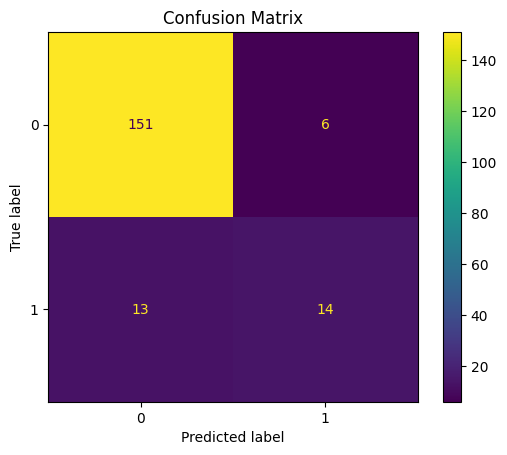

In [19]:
cm=confusion_matrix(y_test, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


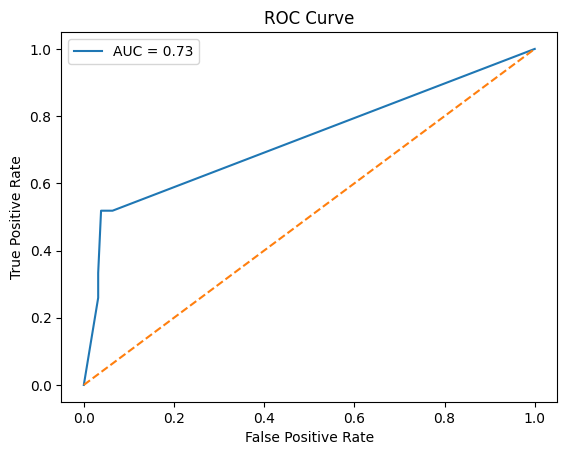

In [20]:
y_prob=pipe.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc=auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

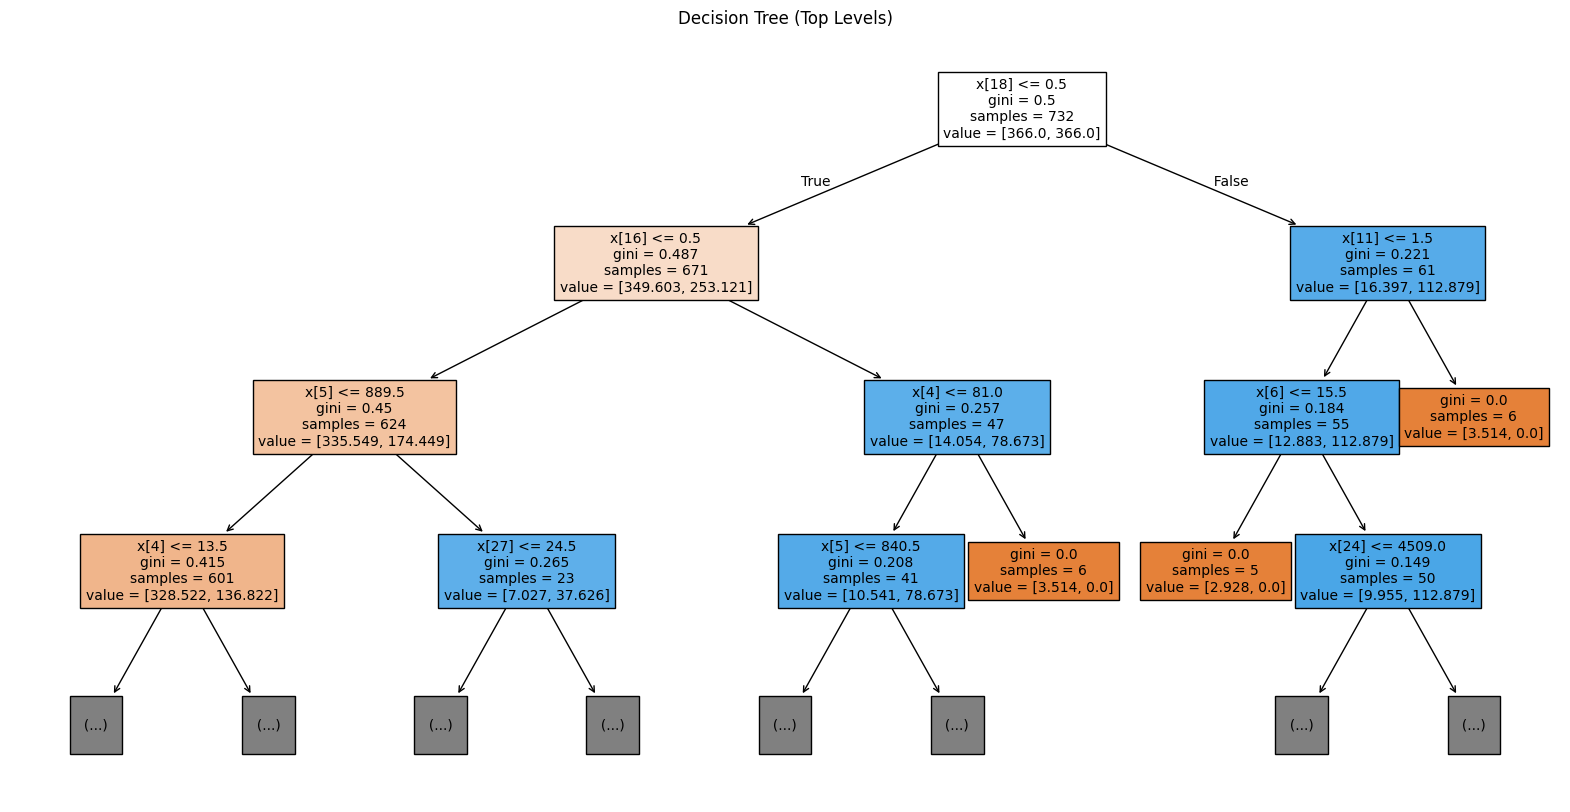

In [13]:
best_tree = pipe.named_steps['model'].best_estimator_
plt.figure(figsize=(20,10))
plot_tree(best_tree, filled=True, max_depth=3, fontsize=10)
plt.title("Decision Tree (Top Levels)")
plt.show()